In [1]:

from spm_agent.states.image_analysis_state import AnalysisState

from langgraph.graph import StateGraph, START, END

In [2]:
# import os
# import numpy as np
# from matplotlib.figure import Figure


# def segment_sspfm_loops(channels: dict, out_dir, skip_frac: float = 0.2,
#                         exclude=("Bias", "Raw", "ZSnsr", "Defl", "Phas2"), add_xy: bool = True) -> dict:
#     """
#     Segment an SS-PFM (DART) measurement into in-field / out-of-field loops.

#     channels : 'file_channels' dict from state (needs 'array_path', 'units');
#                must contain a Bias channel.
#     out_dir  : directory for the .npy loops and the overview .png
#     skip_frac: fraction of samples dropped at the start of each bias segment
#                (transient after the bias step)

#     Saves per channel: {title}_on.npy, {title}_off.npy
#     Saves bias axes:   bias_on.npy / bias_off.npy (x-axis of the loops)
#     Saves overview:    loops_overview.png
#     """
#     os.makedirs(out_dir, exist_ok=True)

#     bias_key = next(k for k, c in channels.items() if c["title"].startswith("Bias"))
#     bias = np.load(channels[bias_key]["array_path"]).ravel()

#     # 1) keep only acquired samples (NaN padding at start/end)
#     finite = np.isfinite(bias)
#     bias_f = bias[finite]

#     # 2) run-length encode constant-bias segments
#     change = np.where(np.abs(np.diff(bias_f)) > 1e-9)[0] + 1
#     bounds = np.concatenate([[0], change, [len(bias_f)]])

#     # 3) classify segments; off-field inherits the preceding pulse bias
#     tol = 1e-3 * np.nanmax(np.abs(bias_f))
#     on_slices, off_slices, on_bias, off_bias = [], [], [], []
#     last_pulse = None
#     for s, e in zip(bounds[:-1], bounds[1:]):
#         v = bias_f[s]
#         s_eff = s + max(1, int(np.ceil((e - s) * skip_frac)))
#         if s_eff >= e:
#             continue
#         if np.abs(v) > tol:                      # on-field segment
#             on_slices.append((s_eff, e)); on_bias.append(v); last_pulse = v
#         elif last_pulse is not None:             # off-field, after a pulse
#             off_slices.append((s_eff, e)); off_bias.append(last_pulse)

#     bias_on = np.asarray(on_bias, dtype=np.float32)
#     bias_off = np.asarray(off_bias, dtype=np.float32)
#     np.save(os.path.join(out_dir, "bias_on.npy"), bias_on)
#     np.save(os.path.join(out_dir, "bias_off.npy"), bias_off)

#     # 4) average each segment for every channel
#     loops = {}
#     for k, ch in channels.items():
#         title = ch["title"]
#         if any(title.startswith(x) for x in exclude):
#             continue
#         y = np.load(ch["array_path"]).ravel()
#         if y.size != bias.size:
#             continue
#         y = y[finite]
#         y_on = np.array([np.nanmean(y[s:e]) for s, e in on_slices], dtype=np.float32)
#         y_off = np.array([np.nanmean(y[s:e]) for s, e in off_slices], dtype=np.float32)
#         p_on = os.path.join(out_dir, f"{title}_on.npy")
#         p_off = os.path.join(out_dir, f"{title}_off.npy")
#         np.save(p_on, y_on); np.save(p_off, y_off)
#         loops[title] = {"on_path": p_on, "off_path": p_off,
#                         "units": ch.get("units", ""), "n_points": int(y_on.size)}

#     # ---- 4a) collect raw traces: measured + derived X/Y ----------------
#     traces = {}   # title -> (raw_array, units)
#     for k, ch in channels.items():
#         title = ch["title"]
#         if any(title.startswith(x) for x in exclude):
#             continue
#         y = np.load(ch["array_path"]).ravel()
#         if y.size != bias.size:
#             continue
#         traces[title] = (y, ch.get("units", ""))

#     if add_xy and "Amp" in traces and "Phase" in traces:
#         a, units = traces["Amp"]
#         phi = np.deg2rad(traces["Phase"][0])
#         traces["X"] = (a * np.cos(phi), units)   # piezoresponse
#         traces["Y"] = (a * np.sin(phi), units)   # quadrature

#     # ---- 4b) segment-average every trace -------------------------------
#     loops = {}
#     for title, (y, units) in traces.items():
#         y = y[finite]
#         y_on = np.array([np.nanmean(y[s:e]) for s, e in on_slices], dtype=np.float32)
#         y_off = np.array([np.nanmean(y[s:e]) for s, e in off_slices], dtype=np.float32)
#         p_on = os.path.join(out_dir, f"{title}_on.npy")
#         p_off = os.path.join(out_dir, f"{title}_off.npy")
#         np.save(p_on, y_on); np.save(p_off, y_off)
#         loops[title] = {"on_path": p_on, "off_path": p_off,
#                         "units": units, "n_points": int(y_on.size)}

#     # 5) overview figure: rows = channels, cols = in-field / out-of-field
#     fig = Figure(figsize=(8, 2.4 * len(loops)), dpi=120)
#     axs = fig.subplots(len(loops), 2, squeeze=False, sharex=True)
#     for r, (title, info) in enumerate(loops.items()):
#         for c, (x, suffix) in enumerate([(bias_on, "on"), (bias_off, "off")]):
#             y = np.load(info[f"{suffix}_path"])
#             axs[r][c].plot(x, y, ".-", lw=0.7, ms=2)
#             axs[r][c].set_ylabel(f"{title} [{info['units']}]", fontsize=8)
#             axs[r][c].grid(True, alpha=0.3)
#             if r == 0:
#                 axs[r][c].set_title(["in-field", "out-of-field"][c])
#     for c in range(2):
#         axs[-1][c].set_xlabel("Bias [V]")
#     fig.tight_layout()
#     fig_path = os.path.join(out_dir, "loops_overview.png")
#     fig.savefig(fig_path)

#     return {"bias_on_path": os.path.join(out_dir, "bias_on.npy"),
#             "bias_off_path": os.path.join(out_dir, "bias_off.npy"),
#             "loops": loops, "overview_path": fig_path,
#             "n_pulses": int(bias_on.size)}

# def classify_measurement(arrays: dict[str, np.ndarray]) -> str:
#     """Classify a measurement as 'image', 'loop' (SS-PFM), or 'spectrum'.
#     arrays: {title: np.ndarray} of the file's channels."""
#     if any(a.ndim >= 2 and min(a.shape) > 1 for a in arrays.values()):
#         return "image"

#     bias = next((a for t, a in arrays.items() if t.startswith("Bias")), None)
#     if bias is None:
#         return "spectrum"

#     b = bias.ravel()
#     b = b[np.isfinite(b)]
#     if b.size < 100 or np.max(np.abs(b)) < 1e-6:
#         return "spectrum"

#     change = np.where(np.abs(np.diff(b)) > 1e-9)[0] + 1
#     bounds = np.concatenate([[0], change, [len(b)]])
#     lens = np.diff(bounds)
#     vals = b[bounds[:-1]]

#     dwell  = (lens >= 3).mean()                        # piecewise-constant
#     zero   = np.abs(vals) < 1e-3 * np.abs(b).max()     # off-field segments
#     altern = (np.diff(zero.astype(int)) != 0).mean()   # on/off interleaving

#     if len(lens) >= 20 and dwell > 0.8 and 0.2 < zero.mean() < 0.8 and altern > 0.8:
#         return "loop"
#     return "spectrum"

In [3]:
from spm_agent.nodes.agentic_segmentation_node import agentic_segmentation_node
from spm_agent.nodes.channel_recommendation_node import channel_recommendation_node
from spm_agent.nodes.set_experiment_tasks_node import make_experiment_tasks_node
from spm_agent.nodes.importance_map_node import importance_map_node
from spm_agent.nodes.build_loop_node import build_loop_node
from spm_agent.nodes.readfile_node import readfile_node
from spm_agent.nodes.route_by_meas_kind_node import route_by_kind
from spm_agent.nodes.loop_params_node import loop_params_node

EXPERIMENT_TASKS = [
    # "Select a diverse measurement set",
    # "Map switching asymmetry across opposite domains",
    "Compare switching inside domains vs near domain walls",
    "Study wall-mediated switching"
]

# --- image subgraph: the whole existing chain, compiled separately ---
img = StateGraph(AnalysisState)
img.add_node("channel_recommendation", channel_recommendation_node)
img.add_node("segmentation", agentic_segmentation_node)
img.add_node("set_tasks", make_experiment_tasks_node(EXPERIMENT_TASKS)) # type: ignore
img.add_node("importance_map", importance_map_node)
img.add_edge(START, "channel_recommendation")
img.add_edge("channel_recommendation", "segmentation")
img.add_edge("segmentation", "set_tasks")
img.add_edge("set_tasks", "importance_map")
img.add_edge("importance_map", END)
image_graph = img.compile()

# --- loop subgraph, same idea ---
lp = StateGraph(AnalysisState)
lp.add_node("build_loop", build_loop_node)
lp.add_node("loop_params", loop_params_node)
# later: lp.add_node("loop_params", ...), lp.add_node("loop_review", ...)
lp.add_edge(START, "build_loop")
lp.add_edge("build_loop", "loop_params")
lp.add_edge("loop_params", END)
loop_graph = lp.compile()

# --- parent analysis graph ---
builder = StateGraph(AnalysisState)
builder.add_node("readfile", readfile_node)
builder.add_node("image_analysis", image_graph)     # compiled graph as node
builder.add_node("loop_analysis", loop_graph)

builder.add_edge(START, "readfile")
builder.add_conditional_edges("readfile", route_by_kind,
                              {"image": "image_analysis",
                               "loop": "loop_analysis",
                               "spectrum": END})


builder.add_edge("image_analysis", END)
builder.add_edge("loop_analysis", END)

In [4]:
im_graph = builder.compile()

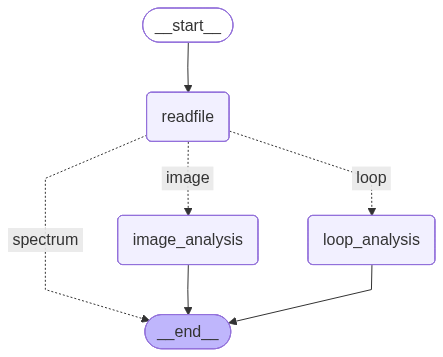

In [5]:
im_graph

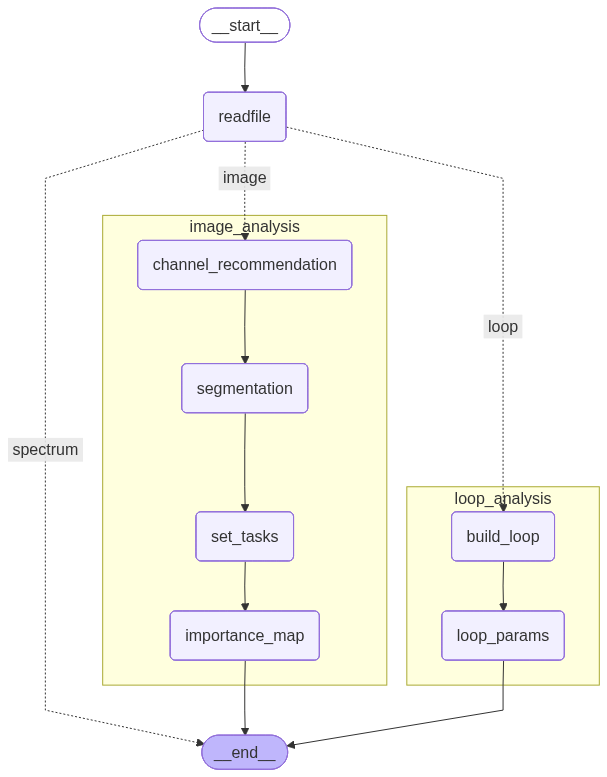

In [6]:
from IPython.display import Image
Image(im_graph.get_graph(xray=True).draw_mermaid_png())

In [7]:
res = await im_graph.ainvoke({"file_path": r"/Users/borisslautin/Downloads/PLZT/PLZT_0005.ibw"})

loop


In [8]:
res['loop_params']

{'off': LoopParams(phase_offset_deg=40.19422436622513, quadrature_residual=0.06632684622225873, n_cycles=2, branch_rms_noise=1.8381751841016884e-11, sat_at_vplus=-3.237363558030871e-10, sat_at_vminus=2.3815363628454155e-10, response_offset=-4.2791359759272785e-11, v_c_rising=2.9916822186803786, v_c_falling=-2.740020133753598, imprint_v=0.12583104246339039, loop_width_v=5.7317023524339765, remnant_rising=2.2510163588399466e-10, remnant_falling=-3.313756972806879e-10, loop_height=5.564773331646826e-10, loop_area_per_cycle=3.6845629361267154e-09, direction='cw', annotated_path='/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/spm_agent/.cashe/loops/loop_off_annotated.png'),
 'on': LoopParams(phase_offset_deg=45.11320685615507, quadrature_residual=0.14003361190777253, n_cycles=2, branch_rms_noise=4.150787385673233e-11, sat_at_vplus=-9.486647391235808e-11, sat_at_vminus=-1.2937322443908517e-11, response_offset=-5.39018981781333e-11, v_c_rising=5.2996310447592645, v_c_falling=-5.929

In [9]:
from spm_agent.utils.channel_utils import load_array

In [10]:
ar = load_array("/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/spm_agent/.cashe/current/Amp.npy")

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline 

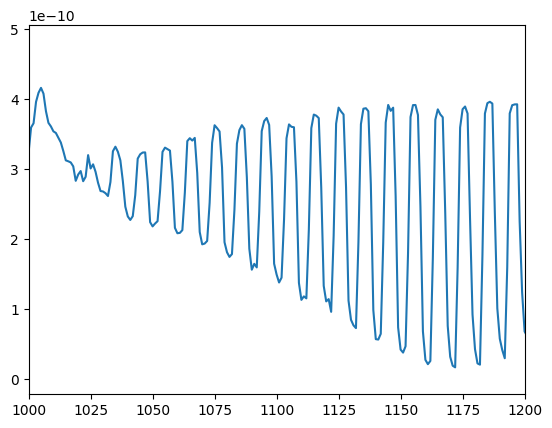

In [12]:
plt.plot(ar)
plt.xlim(1000, 1200)
plt.show()